# SBND flux plots (gsimple)

This notebook mirrors the figures in [`dk2nu.ipynb`](dk2nu.ipynb), but reads **BNB gsimple**
ROOT flux files (ray samples with per-entry weights) instead of merged voxel `pkl` grids.

**Coordinates:** ROOT stores vertex positions in **meters**; `load_gsimple` converts them to
**cm** (`vtxx`, `vtxy`, `vtxz`). All projection planes and window cuts use **cm** along the beam.

**Exposure:** `wgt` is left as in the file; after concatenating many ROOT files, spectra use
`TOTAL_POT = sum` of each file's meta POT so the estimate is **`sum(wgt) / TOTAL_POT`**, not
`sum(wgt / POT_file)` (which would over-count by ~the number of files).

**Ray-traced FV volumes:** `FV_split` and `FV_split_truncY` use a track-length
volume average ($\sum w_i L_i / (V\,\mathrm{POT})$), not the $z$-slab plane average.
For all files, run [`gsimple_batch.py`](gsimple_batch.py) (also writes
`raytrace_flux_histograms.npz`). Cross-check against
[`gsimple_raytrace_batch.py`](gsimple_raytrace_batch.py) in
[`compare_gsimple_raytrace_batch.ipynb`](compare_gsimple_raytrace_batch.ipynb).


In [1]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import uproot
from tqdm import tqdm

try:
    plt.style.use("../numucc_1p0pi/presentation.mplstyle")
except OSError:
    pass


## Configuration and load paths


In [2]:
GSIMPLE_DIR = (
    "/cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/"
    "fluxFiles/bnb/BooNEtoGSimple/configK-v1/july2023/neutrinoMode/"
)

# Number of files to process (set to None to process all)
N_FILES = 100

# Energy bins: 0–4 GeV in 50 MeV steps (match dk2nu display range)
E_BINS = np.linspace(0.0, 4.0, 81)
BIN_CENTERS = 0.5 * (E_BINS[:-1] + E_BINS[1:])

# Slab centers along z [cm] for flux-window scans (same role as dk2nu z slabs)
Z_POSITIONS_CM = np.linspace(0.0, 500.0, 26)

# SBND-style rectangular windows in cm on the projected (x, y) plane (AV / legacy plots)
SBND_VOLUME = dict(z_range_cm=(0.0, 500.0), y_range=(-200.0, 200.0), x_range=(-200.0, 200.0))
FLUX_WINDOW_XY = dict(x_range=(-200.0, 200.0), y_range=(-200.0, 200.0))

FACE_Z_CM = 0.0
DOWNSTREAM_FACE_Z_CM = FACE_Z_CM + 500.0

PDG_BY_FLAVOR = {
    "nue": 12,
    "nuebar": -12,
    "numu": 14,
    "numubar": -14,
}
FLAVORS = list(PDG_BY_FLAVOR.keys())
FLAVOR_LATEX = {
    "nue":     r"$\nu_e$",
    "nuebar":  r"$\bar{\nu}_e$",
    "numu":    r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
}

face_windows = {
    r"AV ($\pm$200, $\pm$200)":          dict(x_range=(-200.0, 200.0), y_range=(-200.0, 200.0)),
    r"FV ($\pm$190, $\pm$190)":         dict(x_range=(-190.0, 190.0), y_range=(-190.0, 190.0)),
    r"FV 2 ($\pm$190, [-190,100])":    dict(x_range=(-190.0, 190.0), y_range=(-190.0, 100.0)),
}

# Ray-traced FV volumes (canonical geometry; shared with gsimple_raytrace.ipynb)
from raytrace_volume_defs import (
    FV_SPLIT_BOXES,
    FV_SPLIT_TRUNCY_BOXES,
    RAYTRACE_VOLUME_DEFS,
    RAYTRACE_VOLUME_LABEL,
    SLAB_COMPARE_Z_RANGE_CM,
    SLAB_Z_RANGE_FV_CM,
    mask_xy_in_volume_at_z,
    plane_area_m2_at_z,
)


## Explore file structure


In [63]:
all_files = sorted(glob.glob(os.path.join(GSIMPLE_DIR, "*.root")))
print(f"Found {len(all_files)} files")

sample_file = all_files[0]
print("Sample file:", sample_file)

with uproot.open(sample_file) as f:
    print("\nKeys:", f.keys())

    print("\n--- flux tree branches ---")
    tree = f["flux"]
    for k in tree.keys():
        print(" ", k)

    print("\n--- meta tree branches ---")
    meta_key = next((k for k in f.keys() if "meta" in k.lower()), None)
    if meta_key:
        meta = f[meta_key]
        for k in meta.keys():
            print(" ", k)
        pot_key = next((k for k in meta.keys() if "proton" in k.lower()), None)
        if pot_key:
            val = meta[pot_key].array(library="np")[0]
            print(f"\n  First entry of '{pot_key}': {val:.6g}")
    else:
        print("  (no meta tree found)")


Found 5000 files
Sample file: /cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/fluxFiles/bnb/BooNEtoGSimple/configK-v1/july2023/neutrinoMode/gsimple_april07_baseline_0000_redecay_wkaonwgh.root

Keys: ['flux;1', 'meta;1']

--- flux tree branches ---
  entry
  entry/wgt
  entry/vtxx
  entry/vtxy
  entry/vtxz
  entry/vtxt
  entry/dist
  entry/px
  entry/py
  entry/pz
  entry/E
  entry/pdg
  entry/metakey
  numi
  numi/tpx
  numi/tpy
  numi/tpz
  numi/vx
  numi/vy
  numi/vz
  numi/pdpx
  numi/pdpy
  numi/pdpz
  numi/pppx
  numi/pppy
  numi/pppz
  numi/ndecay
  numi/ptype
  numi/ppmedium
  numi/tptype
  numi/run
  numi/evtno
  numi/entryno
  aux
  aux/auxint
  aux/auxdbl

--- meta tree branches ---
  meta
  meta/TObject
  meta/TObject/fUniqueID
  meta/TObject/fBits
  meta/pdglist
  meta/maxEnergy
  meta/minWgt
  meta/maxWgt
  meta/protons
  meta/windowBase[3]
  meta/windowDir1[3]
  meta/windowDir2[3]
  meta/auxintname
  meta/auxdblname
  meta/infiles
  meta/seed
  meta/met

## Load gsimple entries (all flavors)


In [64]:
def _get_pot(f):
    # Read POT from the meta tree of an open uproot file.
    meta_key = next((k for k in f.keys() if "meta" in k.lower()), None)
    if meta_key is None:
        raise RuntimeError("No meta tree found; cannot read POT.")
    meta = f[meta_key]
    pot_key = next((k for k in meta.keys() if "proton" in k.lower()), None)
    if pot_key is None:
        raise RuntimeError(f"No 'protons' branch found in meta tree; keys = {list(meta.keys())}")
    return float(meta[pot_key].array(library="np").sum())


def load_gsimple(filename):
    # Load all neutrino entries from a single gsimple ROOT file.
    # Branch `wgt` is the GENIE gsimple nu weight (see GSimpleNtpFlux / GSimpleNtpEntry).
    # Do not divide by file POT here: when stacking many files, flux must be normalized by
    # *total* POT sum(wgt)/sum(POT), not sum(wgt/P_k).
    # Coordinates are converted to cm; momenta and energy stay in GeV.
    with uproot.open(filename) as f:
        pot = _get_pot(f)
        tree = f["flux"]
        keys = tree.keys()
        if "entry/pdg" in keys:
            prefix = "entry/"
        elif "pdg" in keys:
            prefix = ""
        else:
            raise RuntimeError(f"Cannot find 'pdg' branch in {filename}; keys = {list(keys)}")

        branches = [
            prefix + "pdg",
            prefix + "wgt",
            prefix + "vtxx",
            prefix + "vtxy",
            prefix + "vtxz",
            prefix + "px",
            prefix + "py",
            prefix + "pz",
            prefix + "E",
        ]
        arr = tree.arrays(branches, library="np")

    pdg = arr[prefix + "pdg"]
    return {
        "pot": pot,
        "pdg": pdg,
        "wgt": arr[prefix + "wgt"],
        "vtxx": arr[prefix + "vtxx"] * 100.0,
        "vtxy": arr[prefix + "vtxy"] * 100.0,
        "vtxz": arr[prefix + "vtxz"] * 100.0,
        "px": arr[prefix + "px"],
        "py": arr[prefix + "py"],
        "pz": arr[prefix + "pz"],
        "E": arr[prefix + "E"],
    }


In [65]:
files_to_process = all_files[:N_FILES] if N_FILES is not None else all_files
print(f"Processing {len(files_to_process)} file(s)…")

chunks = []
for fpath in tqdm(files_to_process):
    try:
        chunks.append(load_gsimple(fpath))
    except Exception as e:
        print(f"  [skip] {os.path.basename(fpath)}: {e}")

array_keys = [k for k in chunks[0].keys() if k != "pot"]
data = {k: np.concatenate([c[k] for c in chunks]) for k in array_keys}
TOTAL_POT = float(sum(c["pot"] for c in chunks))

print(f"Total entries : {len(data['E']):,}")
print(f"Total simulated POT (sum over files): {TOTAL_POT:.4g}")

p_mag = np.sqrt(data["px"]**2 + data["py"]**2 + data["pz"]**2)
data["dx"] = data["px"] / p_mag
data["dy"] = data["py"] / p_mag
data["dz"] = data["pz"] / p_mag


Processing 100 file(s)…


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:17<00:00,  5.85it/s]


Total entries : 15,105,787
Total simulated POT (sum over files): 1e+09


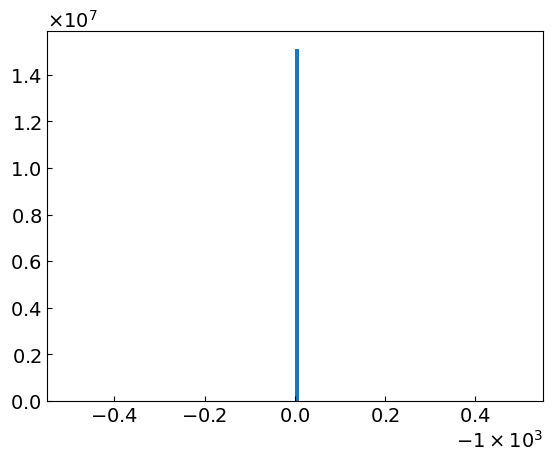

In [66]:
# neutrino vertex is -10m upstream of detector face
plt.hist(data["vtxz"], bins=100)
plt.show();

## Plot helpers

GENIE gsimple entries carry a per-ray **`wgt`**. For a *single* file, `histogram(..., wgt) / POT`
is the usual per-POT estimate; when **stacking many files**, each file must not carry its
own `1/POT` factor into the sum — use **`sum(wgt) / TOTAL_POT`** with `TOTAL_POT = sum_k POT_k`
(GENIE accumulates weights against file POT the same way).

Weighted histograms give neutrino yield in each energy bin per **total stacked exposure**.
Dividing by the transverse window area (m$^2$) turns that into an average **flux density**
$\phi$ in $\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per bin, comparable to the dk2nu voxel average
(`flux` in the pkl is already per-POT; dk2nu plots divide by `n_\mathrm{vox}\,A_\mathrm{voxel}$`).


In [3]:
def window_area_m2(x_range, y_range):
    return (x_range[1] - x_range[0]) * 1.0e-2 * (y_range[1] - y_range[0]) * 1.0e-2


def project_to_z(data, z_target_cm):
    # Project each ray to z = z_target_cm [cm], same units as vtxz. Returns (x_cm, y_cm).
    slope_x = data["px"] / data["pz"]
    slope_y = data["py"] / data["pz"]
    dz = z_target_cm - data["vtxz"]
    x_cm = data["vtxx"] + slope_x * dz
    y_cm = data["vtxy"] + slope_y * dz
    return x_cm, y_cm


def mask_xy(x_cm, y_cm, x_range, y_range):
    return (
        (x_cm >= x_range[0]) & (x_cm < x_range[1])
        & (y_cm >= y_range[0]) & (y_cm < y_range[1])
    )


def spectrum_at_plane(data, flavor, z_cm, x_range, y_range):
    # Flux density [/m^2/POT/bin] through a fixed rectangular window at plane z.
    x_cm, y_cm = project_to_z(data, z_cm)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & mask_xy(x_cm, y_cm, x_range, y_range)
    area = window_area_m2(x_range, y_range)
    h, _ = np.histogram(data["E"][m], bins=E_BINS, weights=data["wgt"][m])
    return h / (area * TOTAL_POT)


def spectrum_at_plane_volume(data, flavor, z_cm, boxes):
    # Flux density [/m^2/POT/bin] at z with (x,y) mask matching ray-traced box union.
    x_cm, y_cm = project_to_z(data, z_cm)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & mask_xy_in_volume_at_z(x_cm, y_cm, z_cm, boxes)
    area = plane_area_m2_at_z(z_cm, boxes)
    if area <= 0.0:
        return np.zeros(len(BIN_CENTERS))
    h, _ = np.histogram(data["E"][m], bins=E_BINS, weights=data["wgt"][m])
    return h / (area * TOTAL_POT)


def integrated_flux(spectrum):
    return float(np.sum(spectrum))


def volume_mean_spectrum(data, flavor, z_cm_values, x_range, y_range):
    # Mean of plane spectra over listed z slab centers (fixed rectangular window).
    stacks = [spectrum_at_plane(data, flavor, z, x_range, y_range) for z in z_cm_values]
    return np.mean(np.stack(stacks, axis=0), axis=0)


def volume_mean_spectrum_boxes(data, flavor, z_cm_values, boxes):
    # Mean of plane spectra over z; geometry matches raytrace_volume_defs at each z.
    stacks = [spectrum_at_plane_volume(data, flavor, z, boxes) for z in z_cm_values]
    return np.mean(np.stack(stacks, axis=0), axis=0)


def _slab_t(v, d, lo, hi):
    with np.errstate(divide="ignore", invalid="ignore"):
        t1 = (lo - v) / d
        t2 = (hi - v) / d
    t_near = np.minimum(t1, t2)
    t_far = np.maximum(t1, t2)
    parallel = d == 0
    if np.any(parallel):
        inside = (v >= lo) & (v <= hi)
        t_near = np.where(parallel, np.where(inside, -np.inf, np.inf), t_near)
        t_far = np.where(parallel, np.where(inside, np.inf, -np.inf), t_far)
    return t_near, t_far


def path_length_box(vx, vy, vz, dx, dy, dz, box):
    tx_n, tx_f = _slab_t(vx, dx, *box["x_range"])
    ty_n, ty_f = _slab_t(vy, dy, *box["y_range"])
    tz_n, tz_f = _slab_t(vz, dz, *box["z_range"])
    t_enter = np.maximum.reduce([tx_n, ty_n, tz_n, np.zeros_like(vx)])
    t_exit = np.minimum.reduce([tx_f, ty_f, tz_f])
    return np.maximum(0.0, t_exit - t_enter)


def path_length_volume(data, boxes):
    L = np.zeros_like(data["vtxx"])
    for box in boxes:
        L += path_length_box(
            data["vtxx"], data["vtxy"], data["vtxz"],
            data["dx"], data["dy"], data["dz"], box,
        )
    return L


def volume_cm3(boxes):
    v = 0.0
    for b in boxes:
        v += (
            (b["x_range"][1] - b["x_range"][0])
            * (b["y_range"][1] - b["y_range"][0])
            * (b["z_range"][1] - b["z_range"][0])
        )
    return v


def raytraced_spectrum(data, flavor, boxes, path_lengths=None):
    """Volume-averaged flux [/m^2/POT/bin] via track-length tally."""
    if path_lengths is None:
        path_lengths = path_length_volume(data, boxes)
    V = volume_cm3(boxes)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & (path_lengths > 0)
    h, _ = np.histogram(
        data["E"][m], bins=E_BINS, weights=data["wgt"][m] * path_lengths[m],
    )
    return h * 1.0e4 / (V * TOTAL_POT)


In [4]:
# Slab / raytrace helpers are defined in the cell above (no duplicate definitions).


## Total flux for the SBND detector volume

FV proxy: $x,y \in [-200,200]$ cm and average over plane spectra for
$z$ in `SBND_VOLUME["z_range_cm"]` intersected with `Z_POSITIONS_CM`.


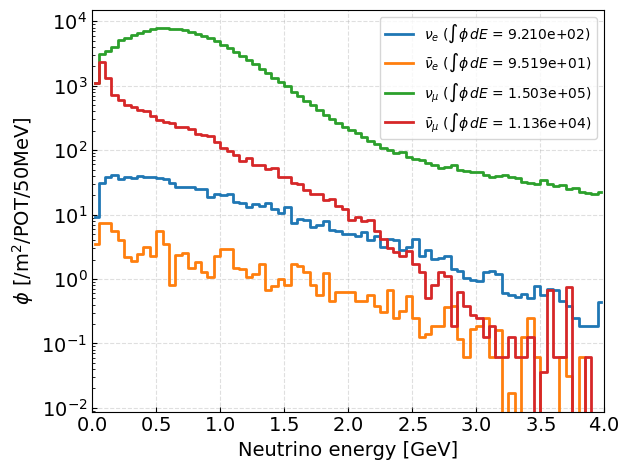

In [69]:
z_lo, z_hi = SBND_VOLUME["z_range_cm"]
z_in_volume = Z_POSITIONS_CM[(Z_POSITIONS_CM >= z_lo) & (Z_POSITIONS_CM <= z_hi)]

fig, ax = plt.subplots()
sbnd_volume_spectra = {}
for flav in FLAVORS:
    spectrum = volume_mean_spectrum(
        data,
        flav,
        z_in_volume,
        SBND_VOLUME["x_range"],
        SBND_VOLUME["y_range"],
    )
    sbnd_volume_spectra[flav] = spectrum
    integ = integrated_flux(spectrum)
    ax.step(
        BIN_CENTERS,
        spectrum,
        where="mid",
        label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})",
    )

ax.set_xlim(0, 4)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


## Ray-traced volume-averaged flux (FV split volumes)

Track-length estimator: $\phi(E) = \sum_i w_i L_i / (V\,\mathrm{POT})$ with $L_i$ the
path length [cm] through the 3D volume and $V$ the union volume in cm$^3$. Units of
the spectrum: $\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per 50 MeV bin.

1. **`FV_split`**: $10 < |x| < 190$, $|y| < 190$, $10 < z < 450$ cm (two anode slabs).
2. **`FV_split_truncY`**: same $10 < |x| < 190$ slabs; $|y| < 190$ for $10 < z < 250$, $-190 < y < 100$ for $250 < z < 450$ cm.


In [ ]:
raytrace_spectra = {vname: {} for vname, _ in RAYTRACE_VOLUME_DEFS}
path_lengths = {}
for vname, boxes in RAYTRACE_VOLUME_DEFS:
    L = path_length_volume(data, boxes)
    path_lengths[vname] = L
    n_hit = int(np.sum(L > 0))
    L_mean = float(np.mean(L[L > 0])) if n_hit else 0.0
    print(
        f"{vname:18s}  V = {volume_cm3(boxes):.4g} cm^3,  "
        f"rays w/ L>0: {n_hit:,},  <L|L>0> = {L_mean:.1f} cm"
    )
    for flav in FLAVORS:
        raytrace_spectra[vname][flav] = raytraced_spectrum(
            data, flav, boxes, path_lengths=L
        )

for vname, _ in RAYTRACE_VOLUME_DEFS:
    fig, ax = plt.subplots()
    for flav in FLAVORS:
        spec = raytrace_spectra[vname][flav]
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS, spec, where="mid",
            label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title(f"Ray-traced — {vname}\n{RAYTRACE_VOLUME_LABEL[vname]}")
    plt.tight_layout()
    plt.show()

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for vname, _ in RAYTRACE_VOLUME_DEFS:
        spec = raytrace_spectra[vname][flav]
        n_rays = int(np.sum(path_lengths[vname][data["pdg"] == PDG_BY_FLAVOR[flav]] > 0))
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS, spec, where="mid",
            label=rf"{vname}, {n_rays:,} rays ($\int$={integ:.2e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_title(f"{FLAVOR_LATEX[flav]} — ray-traced FV volumes")
    plt.tight_layout()
    plt.show()

# Slab (z-plane mean) spectra with the same FV geometry as raytrace
z_lo_fv, z_hi_fv = SLAB_Z_RANGE_FV_CM
z_fv_slabs = np.linspace(z_lo_fv, z_hi_fv, 51)
slab_volume_spectra = {vname: {} for vname, _ in RAYTRACE_VOLUME_DEFS}
for vname, boxes in RAYTRACE_VOLUME_DEFS:
    for flav in FLAVORS:
        slab_volume_spectra[vname][flav] = volume_mean_spectrum_boxes(
            data, flav, z_fv_slabs, boxes
        )


In [ ]:
# Slab vs raytrace (matching FV geometry: x gap, z-dependent y for truncY)
for flav in FLAVORS:
    fig, ax = plt.subplots()
    for vname, boxes in RAYTRACE_VOLUME_DEFS:
        spec_ray = raytrace_spectra[vname][flav]
        spec_slab = slab_volume_spectra[vname][flav]
        ax.step(
            BIN_CENTERS, spec_slab, where="mid",
            label=rf"z-slab {vname} ($\int$={integrated_flux(spec_slab):.2e})",
        )
        ax.step(
            BIN_CENTERS, spec_ray, where="mid", ls="--",
            label=rf"raytrace {vname} ($\int$={integrated_flux(spec_ray):.2e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)
    ax.set_title(f"{FLAVOR_LATEX[flav]} — slab (FV geometry) vs raytrace")
    plt.tight_layout()
    plt.show()


### Save ray-traced spectra (optional, notebook subset)

Uncomment to write a small `.npz` for the current `N_FILES` subset (not for production;
use `gsimple_batch.py` for the full sample).


In [ ]:
# OUT_NB = "raytrace_flux_notebook.npz"
# vol_keys = np.array([v for v, _ in RAYTRACE_VOLUME_DEFS], dtype=object)
# vol_cm3 = np.array([volume_cm3(b) for _, b in RAYTRACE_VOLUME_DEFS])
# phi_nb = np.stack(
#     [[raytrace_spectra[v][f] for f in FLAVORS] for v, _ in RAYTRACE_VOLUME_DEFS],
#     axis=0,
# )
# np.savez_compressed(
#     OUT_NB,
#     total_pot=np.array(TOTAL_POT),
#     E_BINS=E_BINS,
#     BIN_CENTERS=BIN_CENTERS,
#     volume_keys=vol_keys,
#     volume_cm3=vol_cm3,
#     flavors=np.array(FLAVORS, dtype=object),
#     flux_density_wvf=phi_nb,
# )
# print("Wrote", OUT_NB)


## Flux through the flux window at different `z`

The flux window is $x,y \in [-200,200]$ cm for each slab center in `Z_POSITIONS_CM`
(analogous to dk2nu’s one-voxel-thick $z$ slices with the same transverse window). All
$z$ positions are in **cm** (same units as `vtxz` after `load_gsimple`).


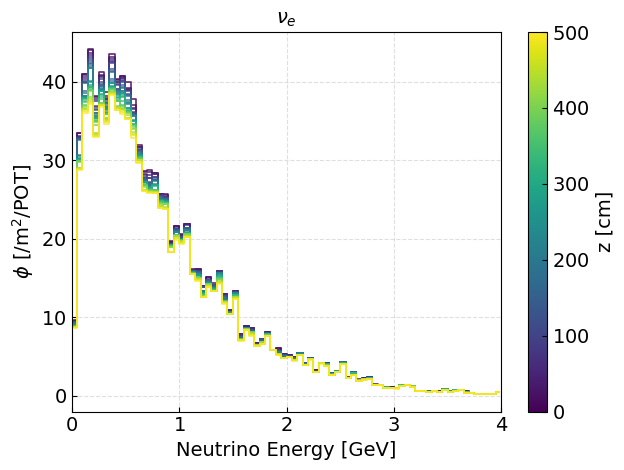

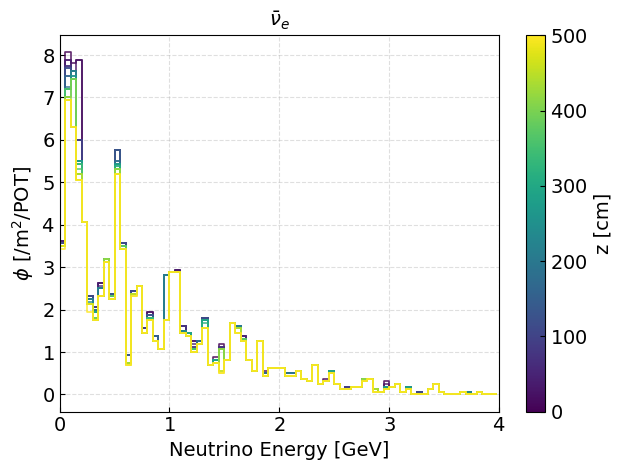

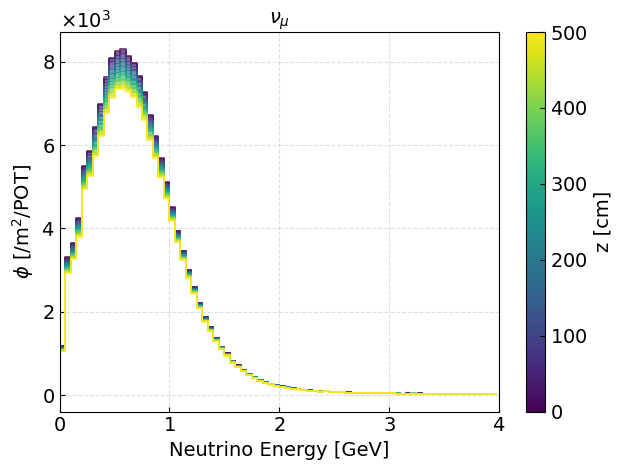

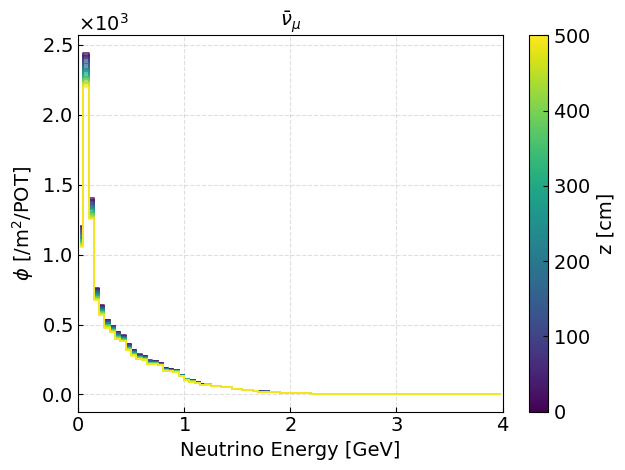

In [70]:
z_slabs = list(Z_POSITIONS_CM)
z_slab_spectra = {flav: np.zeros((len(z_slabs), len(BIN_CENTERS))) for flav in FLAVORS}
z_slab_integ = {flav: np.zeros(len(z_slabs)) for flav in FLAVORS}

for iz, z in enumerate(z_slabs):
    for flav in FLAVORS:
        spec = spectrum_at_plane(data, flav, z, **FLUX_WINDOW_XY)
        z_slab_spectra[flav][iz] = spec
        z_slab_integ[flav][iz] = integrated_flux(spec)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=z_slabs[0], vmax=z_slabs[-1])
for flav in FLAVORS:
    fig, ax = plt.subplots()
    for iz, z in enumerate(z_slabs):
        ax.step(
            BIN_CENTERS,
            z_slab_spectra[flav][iz],
            where="mid",
            color=cmap(norm(z)),
            alpha=0.85,
            linewidth=1.2,
            label=f"z={z:.0f} cm",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="z [cm]")
    plt.tight_layout()
    plt.show()


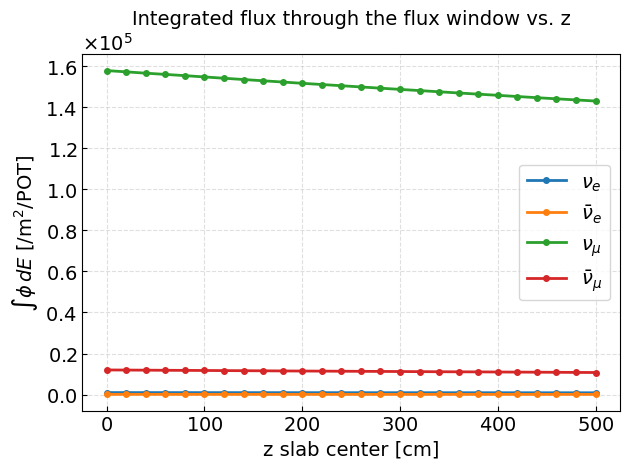

In [73]:
fig, ax = plt.subplots()
for flav in FLAVORS:
    ax.plot(
        z_slabs,
        z_slab_integ[flav],
        marker="o",
        markersize=4,
        label=FLAVOR_LATEX[flav],
    )
ax.set_xlabel("z slab center [cm]")
ax.set_ylabel(r"$\int \phi\,dE$ [/m$^2$/POT]")
ax.set_title("Integrated flux through the flux window vs. z")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Flux at the detector face for different `(x, y)` windows

Upstream face proxy: $z$ slab `FACE_Z_CM` (cm along beam, same as `vtxz`); spectra evaluated
at the slab mid-plane (same role as dk2nu `z \in [11000,11020]` cm on the voxel grid).


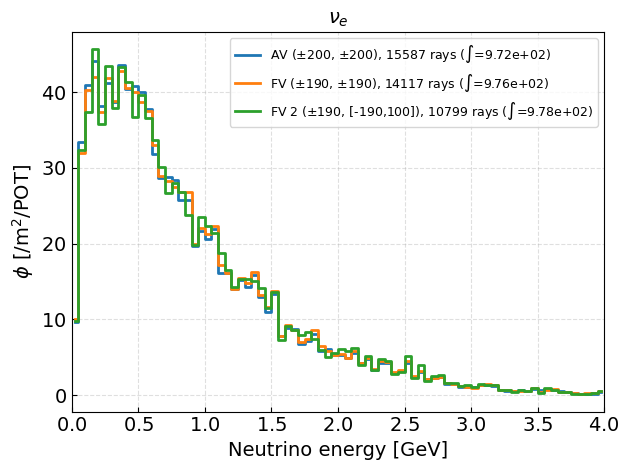

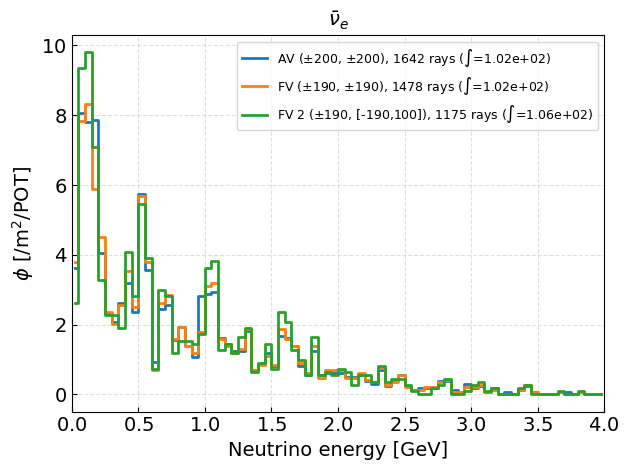

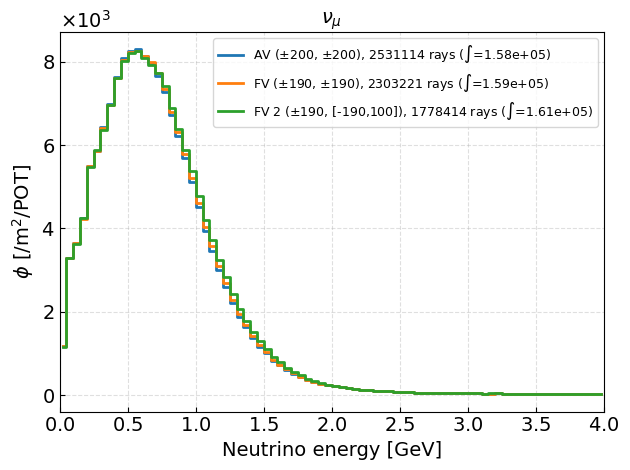

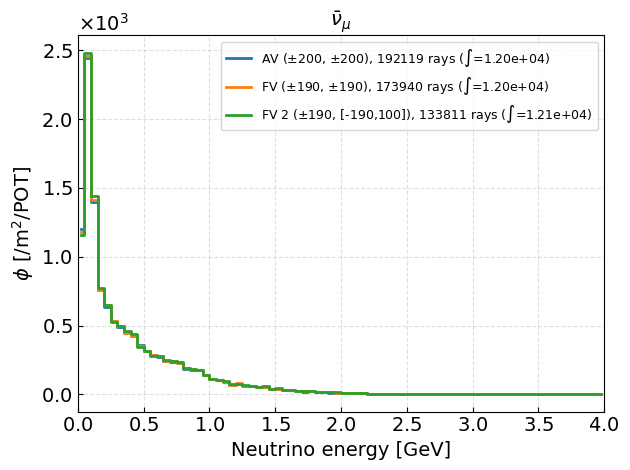

In [75]:
z_face_cm = FACE_Z_CM

face_spectra = {flav: {} for flav in FLAVORS}
for label, win in face_windows.items():
    for flav in FLAVORS:
        spec = spectrum_at_plane(data, flav, z_face_cm, **win)
        x_cm, y_cm = project_to_z(data, z_face_cm)
        m = (data["pdg"] == PDG_BY_FLAVOR[flav]) & mask_xy(x_cm, y_cm, **win)
        n_rays = int(np.sum(m))
        face_spectra[flav][label] = (spec, n_rays)

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for label, (spec, n_rays) in face_spectra[flav].items():
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS,
            spec,
            where="mid",
            label=rf"{label}, {n_rays} rays ($\int$={integ:.2e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.show()


## Combined comparison: volume vs faces


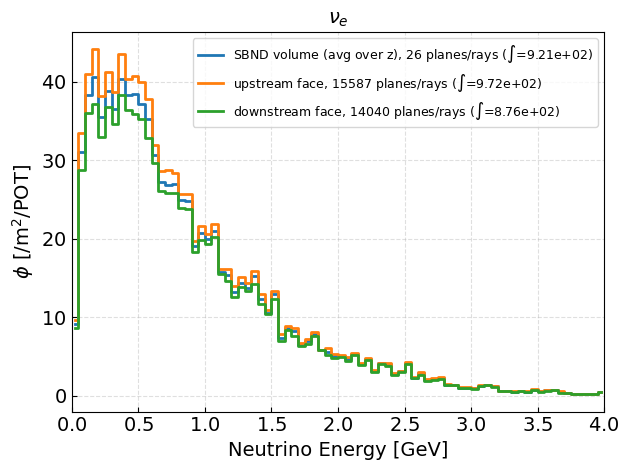

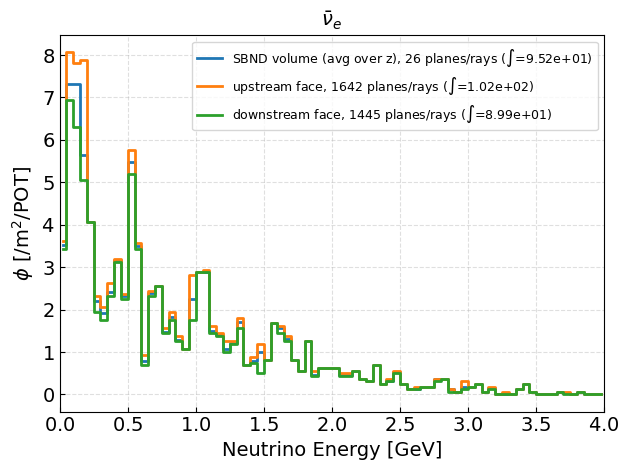

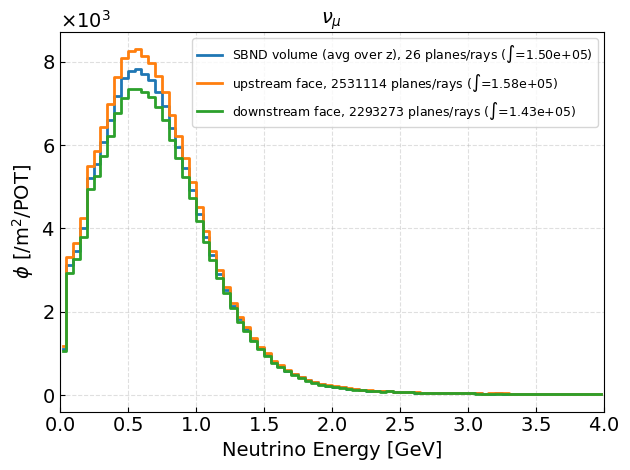

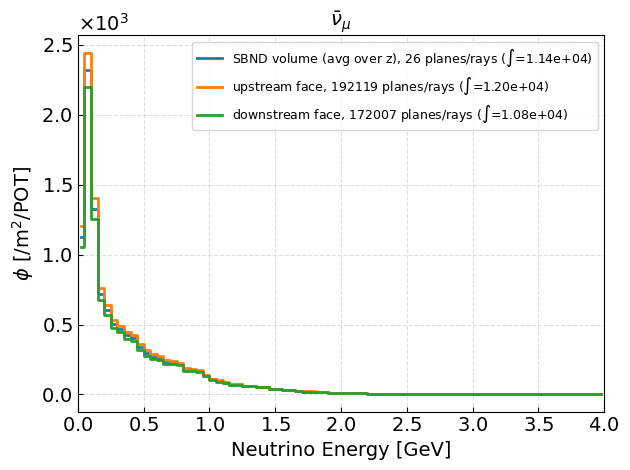

In [76]:
z_up = FACE_Z_CM
z_dn = DOWNSTREAM_FACE_Z_CM

configs = {
    "SBND volume (avg over z)": (
        "volume",
        None,
    ),
    "upstream face": (
        "plane",
        (z_up, -200.0, 200.0, -200.0, 200.0),
    ),
    "downstream face": (
        "plane",
        (z_dn, -200.0, 200.0, -200.0, 200.0),
    ),
}

for flav in FLAVORS:
    fig, ax = plt.subplots()
    for label, (kind, payload) in configs.items():
        if kind == "volume":
            spec = volume_mean_spectrum(
                data,
                flav,
                z_in_volume,
                SBND_VOLUME["x_range"],
                SBND_VOLUME["y_range"],
            )
            n_meta = len(z_in_volume)
        else:
            zm, xmin, xmax, ymin, ymax = payload
            spec = spectrum_at_plane(data, flav, zm, (xmin, xmax), (ymin, ymax))
            x_cm, y_cm = project_to_z(data, zm)
            n_meta = int(
                np.sum(
                    (data["pdg"] == PDG_BY_FLAVOR[flav])
                    & mask_xy(x_cm, y_cm, (xmin, xmax), (ymin, ymax))
                )
            )
        integ = integrated_flux(spec)
        ax.step(
            BIN_CENTERS,
            spec,
            where="mid",
            label=rf"{label}, {n_meta} planes/rays ($\int$={integ:.2e})",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]}")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## Reload flux from `gsimple_batch.py` outputs

If you ran [`gsimple_batch.py`](gsimple_batch.py) (e.g. with `--out-dir` / `--save-npz`), the run directory contains **`flux_histograms.npz`**, **`flux_histograms_meta.json`**, **`processed_files.txt`**, and **`skipped_files.json`**.

Arrays are documented in the script docstring: **`flux_density_zwf`** has shape `(n_z, n_window, n_flavor, n_energy)` in $\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per 50 MeV bin; **`hist_weighted_zwf`** holds raw $\sum wgt$ per bin before dividing by `(window area × total POT)`. Ray-traced FV volumes are in **`flux_density_raytrace_wvf`** with shape `(n_raytrace_volume, n_flavor, n_energy)`.

Set **`BATCH_FLUX_DIR`** in the next cell to the folder that contains `flux_histograms.npz` (defaults to this notebook’s directory).

`gsimple_batch.py` also writes **`raytrace_flux_histograms.npz`** (same schema as
`gsimple_raytrace_batch.py`). Compare the two batch outputs in
[`compare_gsimple_raytrace_batch.ipynb`](compare_gsimple_raytrace_batch.ipynb).


In [6]:
from pathlib import Path
import json

# Folder containing flux_histograms.npz from gsimple_batch.py
BATCH_FLUX_DIR = Path("/exp/sbnd/data/users/munjung/flux/SBND_gsimple")  # change if you saved outputs elsewhere

BATCH_NPZ = BATCH_FLUX_DIR / "flux_histograms.npz"
BATCH_META = BATCH_FLUX_DIR / "flux_histograms_meta.json"

if not BATCH_NPZ.is_file():
    raise FileNotFoundError(
        f"Missing {BATCH_NPZ!s}. Run gsimple_batch.py with --out-dir or --save-npz, "
        "or point BATCH_FLUX_DIR to that directory."
    )

batch = np.load(BATCH_NPZ, allow_pickle=True)
phi_zwf = batch["flux_density_zwf"]  # (n_z, n_window, n_flavor, n_E)
nr_zwf = batch["n_rays_zwf"]
z_batch = batch["z_positions_cm"]
win_keys = list(batch["window_keys"])
flavors_batch = list(batch["flavors"])
BIN_BATCH = batch["BIN_CENTERS"]
E_BINS_BATCH = batch["E_BINS"]
total_pot_batch = float(batch["total_pot"])

# Window index 0 is AV ±200 cm (same geometry as FLUX_WINDOW_XY / SBND AV)
IW_AV = int(win_keys.index("AV_pm200_cm")) if "AV_pm200_cm" in win_keys else 0

if BATCH_META.is_file():
    with open(BATCH_META, encoding="utf-8") as f:
        batch_meta = json.load(f)
    print("Batch meta:", json.dumps({k: batch_meta[k] for k in ("n_files_ok", "n_skipped", "n_files_attempted", "batch_size") if k in batch_meta}, indent=2))
print("total_pot (batch)", total_pot_batch)
print("phi_zwf shape", phi_zwf.shape, "| windows:", win_keys, "| z [cm]:", z_batch[0], "…", z_batch[-1])

# Ray-traced FV volumes (optional; present if batch run includes raytrace tallies)
if "flux_density_raytrace_wvf" in batch.files:
    phi_ray_wvf = batch["flux_density_raytrace_wvf"]
    ray_vol_keys = list(batch["raytrace_volume_keys"])
    ray_vol_cm3 = batch["raytrace_volume_cm3"]
    print("phi_ray_wvf shape", phi_ray_wvf.shape, "| volumes:", ray_vol_keys)
else:
    phi_ray_wvf = ray_vol_keys = ray_vol_cm3 = None
    print("(no raytrace arrays in this .npz — re-run gsimple_batch.py)")


Batch meta: {
  "n_files_ok": 5000,
  "n_skipped": 0,
  "n_files_attempted": 5000,
  "batch_size": 500
}
total_pot (batch) 50000164197.1396
phi_zwf shape (26, 3, 4, 80) | windows: ['AV_pm200_cm', 'FV_pm190_cm', 'FV2_pm190_y-190_100_cm'] | z [cm]: 0.0 … 500.0


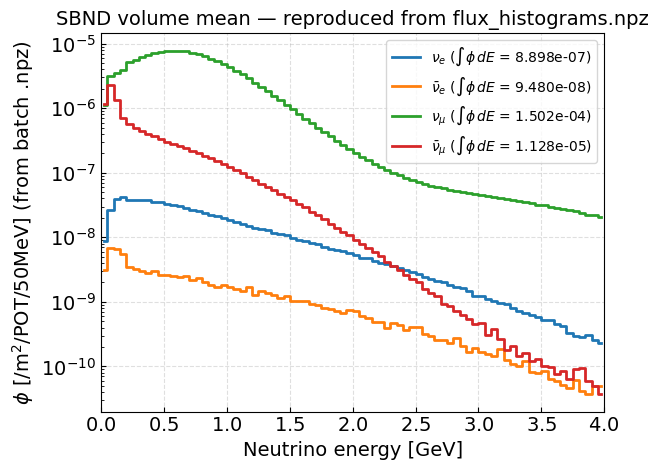

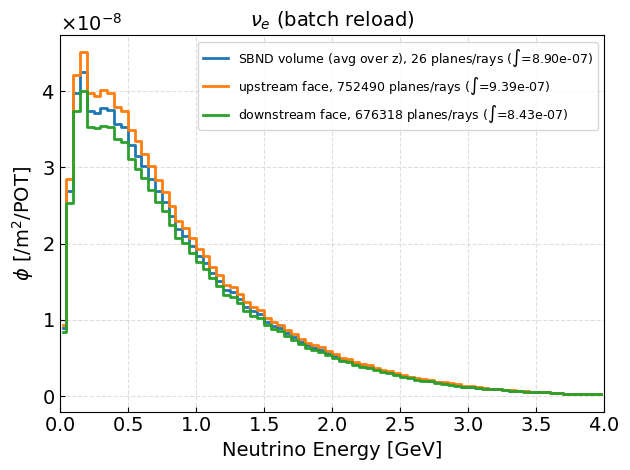

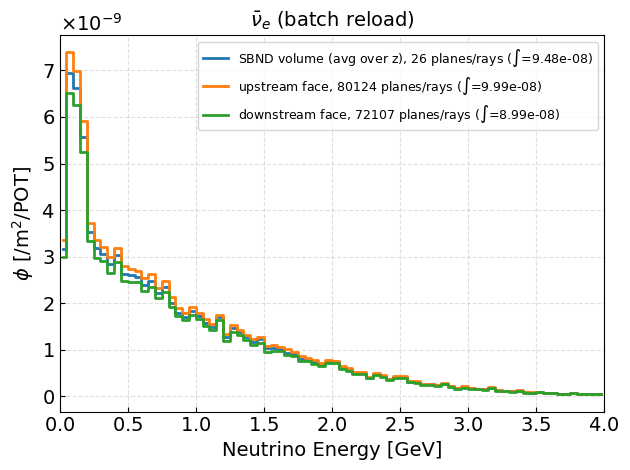

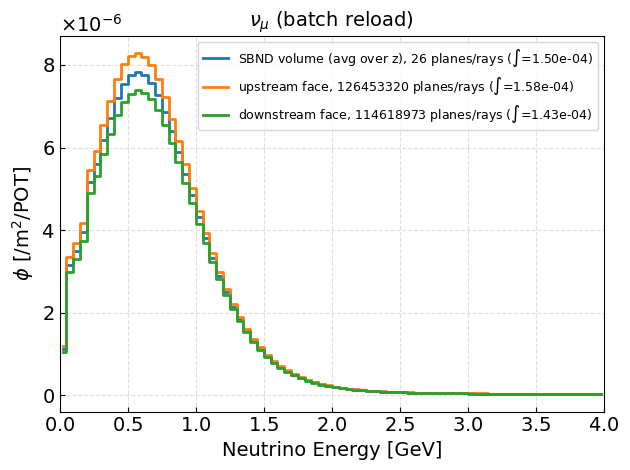

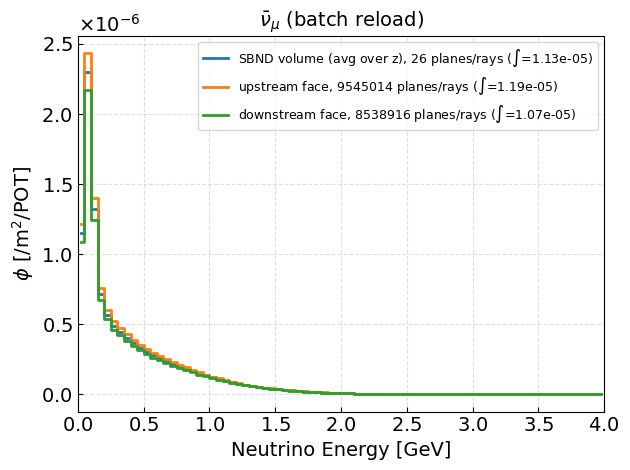

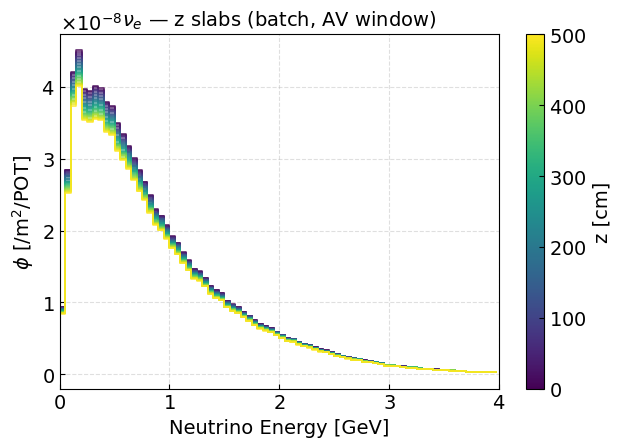

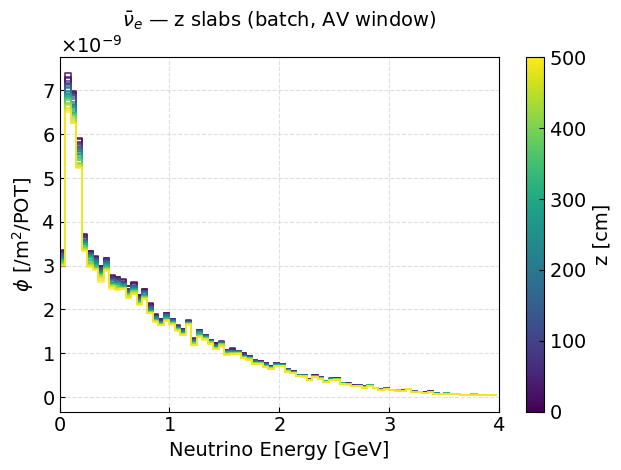

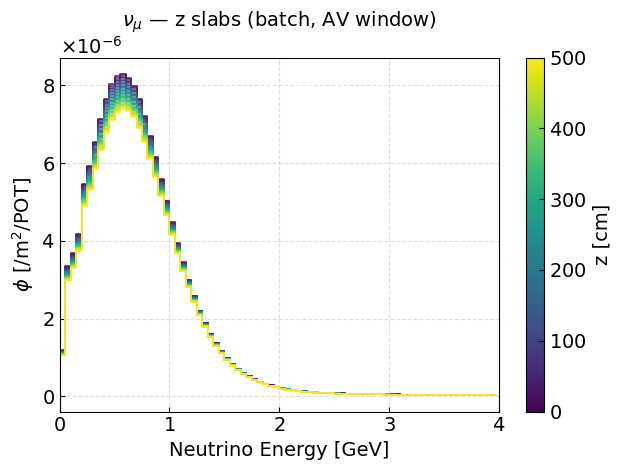

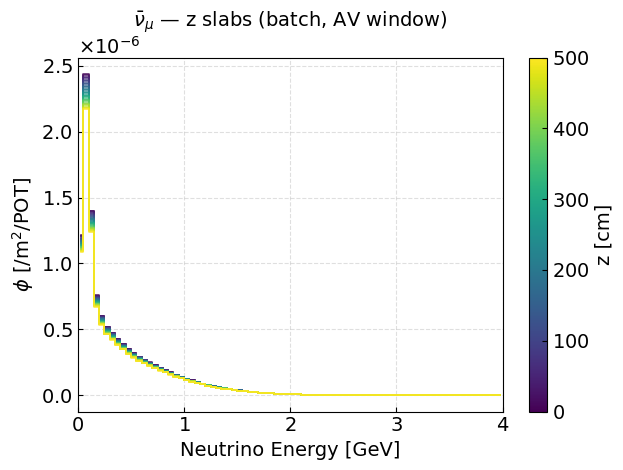

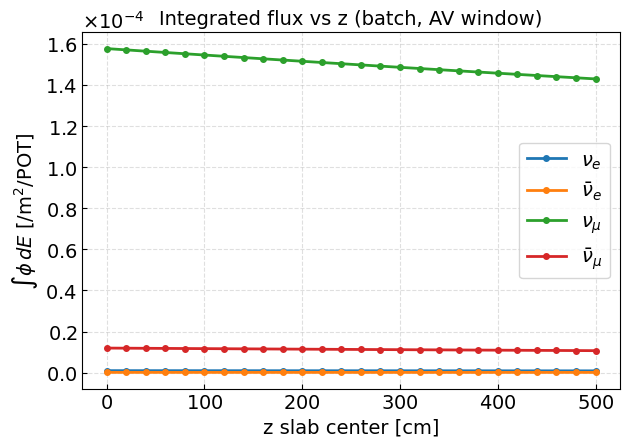

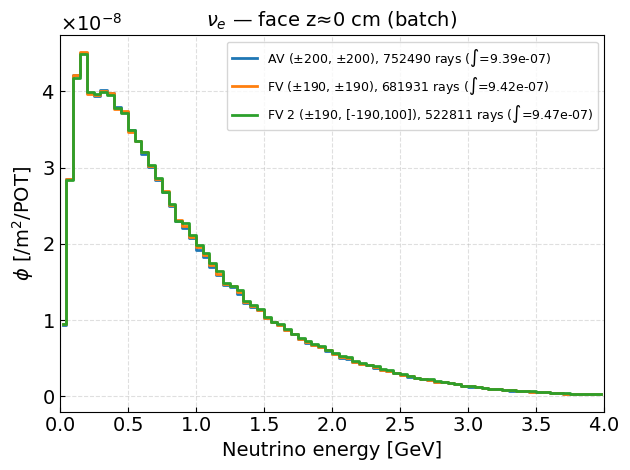

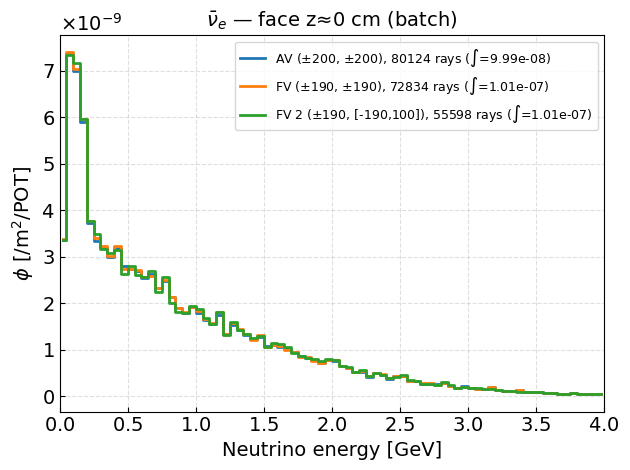

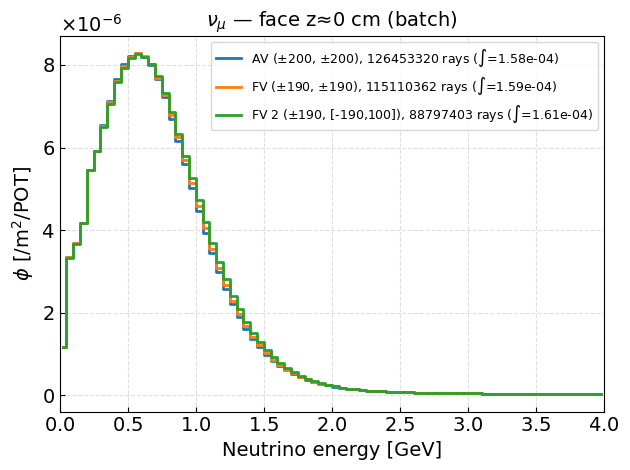

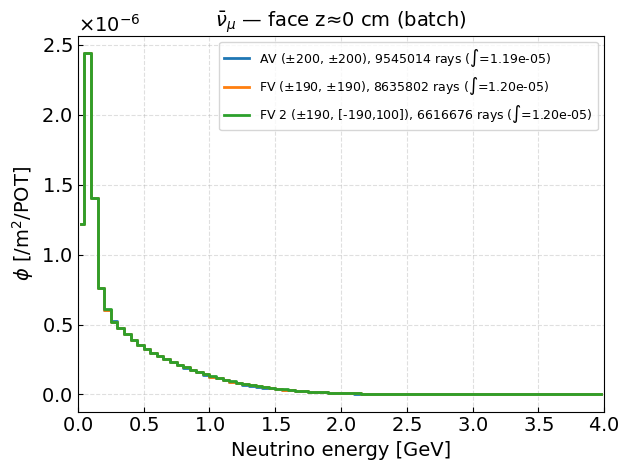

In [7]:
# --- SBND volume-averaged spectrum (AV window, mean over z slabs inside SBND z range) ---
z_lo, z_hi = SBND_VOLUME["z_range_cm"]
iz_vol = np.where((z_batch >= z_lo) & (z_batch <= z_hi))[0]

fig, ax = plt.subplots()
for iflav, flav in enumerate(FLAVORS):
    plane_stack = phi_zwf[iz_vol, IW_AV, iflav, :]
    spec = np.mean(plane_stack, axis=0)
    integ = float(np.sum(spec))
    ax.step(BIN_BATCH, spec, where="mid", label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})")
ax.set_xlim(0, 4)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV] (from batch .npz)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_yscale("log")
plt.title("SBND volume mean — reproduced from flux_histograms.npz")
plt.tight_layout()
plt.show()

# --- Same layout as “Combined comparison: volume vs faces” (AV ±200 at z=0 and z=500) ---
iz0 = int(np.argmin(np.abs(z_batch - FACE_Z_CM)))
iz_dn = int(np.argmin(np.abs(z_batch - DOWNSTREAM_FACE_Z_CM)))

configs_batch = {
    "SBND volume (avg over z)": ("volume", None),
    "upstream face": ("plane", iz0),
    "downstream face": ("plane", iz_dn),
}

for iflav, flav in enumerate(FLAVORS):
    fig, ax = plt.subplots()
    for label, (kind, izp) in configs_batch.items():
        if kind == "volume":
            spec = np.mean(phi_zwf[iz_vol, IW_AV, iflav, :], axis=0)
            n_meta = len(iz_vol)
        else:
            spec = phi_zwf[izp, IW_AV, iflav, :]
            n_meta = int(nr_zwf[izp, IW_AV, iflav])
        integ = float(np.sum(spec))
        ax.step(BIN_BATCH, spec, where="mid", label=rf"{label}, {n_meta} planes/rays ($\int$={integ:.2e})")
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]} (batch reload)")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# --- z-slab fan plot (default AV window) + integrated flux vs z ---
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=float(z_batch[0]), vmax=float(z_batch[-1]))
for iflav, flav in enumerate(FLAVORS):
    fig, ax = plt.subplots()
    for iz, z in enumerate(z_batch):
        ax.step(
            BIN_BATCH,
            phi_zwf[iz, IW_AV, iflav, :],
            where="mid",
            color=cmap(norm(float(z))),
            alpha=0.85,
            linewidth=1.2,
            label=f"z={z:.0f} cm",
        )
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino Energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]} — z slabs (batch, AV window)")
    ax.grid(True, alpha=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="z [cm]")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots()
for iflav, flav in enumerate(FLAVORS):
    integ_z = np.sum(phi_zwf[:, IW_AV, iflav, :], axis=-1)
    ax.plot(z_batch, integ_z, marker="o", markersize=4, label=FLAVOR_LATEX[flav])
ax.set_xlabel("z slab center [cm]")
ax.set_ylabel(r"$\int \phi\,dE$ [/m$^2$/POT]")
ax.set_title("Integrated flux vs z (batch, AV window)")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- Face: all (x,y) windows at z ≈ 0 (one window index per geometry) ---
iz_face = iz0
for iflav, flav in enumerate(FLAVORS):
    fig, ax = plt.subplots()
    for iw, (lbl, _win) in enumerate(face_windows.items()):
        spec = phi_zwf[iz_face, iw, iflav, :]
        n_rays = int(nr_zwf[iz_face, iw, iflav])
        integ = float(np.sum(spec))
        ax.step(BIN_BATCH, spec, where="mid", label=rf"{lbl}, {n_rays} rays ($\int$={integ:.2e})")
    ax.set_xlim(0, 4)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT]")
    ax.set_title(f"{FLAVOR_LATEX[flav]} — face z≈{z_batch[iz_face]:.0f} cm (batch)")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Ray-traced FV volumes from batch .npz ---
if phi_ray_wvf is not None:
    for iv, vname in enumerate(ray_vol_keys):
        fig, ax = plt.subplots()
        for iflav, flav in enumerate(FLAVORS):
            spec = phi_ray_wvf[iv, iflav, :]
            integ = float(np.sum(spec))
            ax.step(
                BIN_BATCH, spec, where="mid",
                label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})",
            )
        ax.set_xlim(0, 4)
        ax.set_xlabel("Neutrino energy [GeV]")
        ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV] (ray-trace, batch)")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=10)
        ax.set_title(f"Ray-traced — {vname}  ($V$={float(ray_vol_cm3[iv]):.3g} cm$^3$)")
        plt.tight_layout()
        plt.show()
